In [1]:
# Libraries
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')
%matplotlib inline
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mpdates

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Input, LSTM, Dense, concatenate
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt


In [2]:
# Load dataset
df_compiled = pd.read_csv('compiled_datasets.csv', parse_dates=['Date'], index_col='Date')
df_compiled.loc['2019-01-01':'2025-01-01'].dropna()
df_compiled.columns.tolist()

['Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'headline',
 'TextBlob_Polarity',
 'TextBlob_Subjectivity',
 'TextBlob_Sentiment',
 'VADER_Score',
 'VADER_Sentiment',
 'Close_Change',
 'VADER_Sentiment_Num',
 'Close_lag_1',
 'VADER_Score_lag_1',
 'Close_lag_2',
 'VADER_Score_lag_2',
 'Close_lag_3',
 'VADER_Score_lag_3',
 'SMA_5',
 'EMA_5',
 'RSI_14',
 'MACD',
 'MACD_signal',
 'MACD_hist']

In [3]:
df_compiled

,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,VADER_Score,...,Close_lag_2,VADER_Score_lag_2,Close_lag_3,VADER_Score_lag_3,SMA_5,EMA_5,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500.0,NaN,0.0000,0.0000,Neutral,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000.0,NaN,0.0000,0.0000,Neutral,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500.0,NaN,0.0000,0.0000,Neutral,0.0000,...,1675.829956,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900.0,NaN,0.0000,0.0000,Neutral,0.0000,...,1669.780029,0.0000,1675.829956,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-09,1667.829956,1684.079956,1667.829956,1679.060059,176278400.0,NaN,0.0000,0.0000,Neutral,0.0000,...,1679.170044,0.0000,1669.780029,0.0000,1673.073999,1673.073999,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400.0,IHH Annual Report 2023 - INSAGE (MSC) SDN BHD ...,0.0000,0.0000,Neutral,0.0000,...,1591.410034,0.9186,1600.089966,-0.0772,1598.053979,1599.343015,48.687258,-3.254057,-3.169868,-0.084189
2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600.0,NaN,0.0000,0.0000,Neutral,0.0000,...,1596.199951,0.0000,1591.410034,0.9186,1600.877979,1604.128660,55.912476,-2.013781,-2.938650,0.924869
2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200.0,"Consulate General of Malaysia, Xian - kln.gov.my",0.0500,0.5000,Neutral,0.0000,...,1602.989990,0.0000,1596.199951,0.0000,1606.487988,1612.132445,63.396201,0.132808,-2.324359,2.457166


In [4]:
# Separate Features for LSTM Model Development
tech_feats = ['SMA_5',
 'EMA_5',
 'RSI_14',
 'MACD',
 'MACD_signal',
 'MACD_hist']

senti_feats = ['TextBlob_Polarity',
 'TextBlob_Subjectivity',
 'TextBlob_Sentiment',
 'VADER_Score',
 'VADER_Sentiment',
 'Close_Change',
 'VADER_Sentiment_Num',
 'Close_lag_1',
 'VADER_Score_lag_1',
 'Close_lag_2',
 'VADER_Score_lag_2',
 'Close_lag_3',
 'VADER_Score_lag_3']


In [5]:
# Re-scale VADER Sentiment
df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_4080\3285919984.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({


In [6]:
# Re-scale TextBlob Sentiment
df_compiled['TextBlob_Sentiment'] = df_compiled['TextBlob_Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_4080\3566160557.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['TextBlob_Sentiment'] = df_compiled['TextBlob_Sentiment'].replace({


In [7]:
df_compiled['VADER_Sentiment'] = pd.to_numeric(df_compiled['VADER_Sentiment'], errors='coerce')
df_compiled['TextBlob_Sentiment'] = pd.to_numeric(df_compiled['TextBlob_Sentiment'], errors='coerce')


In [8]:
# Re-scaler 
scaler_tech = MinMaxScaler()
scaler_senti = MinMaxScaler()
scaler_y = MinMaxScaler()

df_tech = pd.DataFrame(
    scaler_tech.fit_transform(df_compiled[tech_feats]), 
    index=df_compiled.index, 
    columns=tech_feats)

df_senti = pd.DataFrame(
    scaler_senti.fit_transform(df_compiled[senti_feats]), 
    index=df_compiled.index, 
    columns=senti_feats)

df_y = pd.DataFrame(scaler_y.fit_transform(df_compiled[['Close']]), index=df_compiled.index, columns=['Close_norm'])
df_y['Close_norm'] = scaler_y.fit_transform(df_compiled[['Close']])


c:\Users\badar\Desktop\VS Studio\Capstone 1\venv\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\badar\Desktop\VS Studio\Capstone 1\venv\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


df_y = pd.DataFrame(scaler_y.fit_transform(df_compiled[['Close']]), index=df_compiled.index, columns=['Close_norm'])
df_y['Close_norm'] = scaler_y.fit_transform(df_compiled[['Close']])


In [9]:
# Split first (no shuffle!)
train_size = int(len(df_compiled) * 0.8)
train_df = df_compiled.iloc[:train_size]
test_df = df_compiled.iloc[train_size:]

# Fit scalers only on training set
scaler_y = MinMaxScaler()
train_df['Close_norm'] = scaler_y.fit_transform(train_df[['Close']])
test_df['Close_norm'] = scaler_y.transform(test_df[['Close']])

# for scaler tech
scaler_tech = MinMaxScaler()
train_df['Close_norm'] = scaler_tech.fit_transform(train_df[['Close']])
test_df['Close_norm'] = scaler_tech.transform(test_df[['Close']])

# for scaler senti
scaler_senti = MinMaxScaler()
train_df['Close_norm'] = scaler_senti.fit_transform(train_df[['Close']])
test_df['Close_norm'] = scaler_senti.transform(test_df[['Close']])


C:\Users\badar\AppData\Local\Temp\ipykernel_4080\2140569546.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Close_norm'] = scaler_y.fit_transform(train_df[['Close']])
C:\Users\badar\AppData\Local\Temp\ipykernel_4080\2140569546.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Close_norm'] = scaler_y.transform(test_df[['Close']])
C:\Users\badar\AppData\Local\Temp\ipykernel_4080\2140569546.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [10]:
# Create Time-Series Sequences
def create_sequences(df_x, df_y, seq_len=60):
    X, y = [],[]
    for i in range(seq_len, len(df_x)):
        X.append(df_x.iloc[i-seq_len:i].values)
        y.append(df_y.iloc[i].values)
    return np.array(X), np.array(y)

seq_len = 60

X_tech, y = create_sequences(df_tech, df_y, seq_len)
X_senti, _ = create_sequences(df_senti, df_y, seq_len)
y = y.squeeze()

In [11]:
# Split Into Train, Validation, and Test Sets
n = len(X_tech)
i1, i2 = int(n*0.7), int(n*0.9)

Xtech_train, Xtech_val, Xtech_test = X_tech[:i1], X_tech[i1:i2], X_tech[i2:]
Xsenti_train, Xsenti_val, Xsenti_test = X_senti[:i1], X_senti[i1:i2], X_senti[i2:]
y_train, y_val, y_test = y[:i1], y[i1:i2], y[i2:]


Bidirectional LSTM helps capture past and future patterns 

Stacked LSTM layers deepen sequence learning — proven in time-series forecasting 

Dropout & recurrent_dropout combat overfitting per best practices .

BatchNormalization stabilizes training and helps convergence .

Dense layers with Dropout add more modeling power while avoiding over-parameterization.

In [12]:
# Build the Hybrid Two-Stream LSTM Model
tech_in = Input(shape=(seq_len, len(tech_feats)), name='tech_input')
x1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(tech_in)
x1 = BatchNormalization()(x1)
x1 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x1)

senti_in = Input(shape=(seq_len, len(senti_feats)), name='senti_input')
x2 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(senti_in)

# Merge
merged = concatenate([x1, x2])
x = Dense(64, activation='relu')(merged)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, name='pred_close')(x)

model = Model([tech_in, senti_in], output)

# Compile with regression metrics
model.compile(optimizer='adam', loss='mse', metrics=[
        RootMeanSquaredError(name='rmse'),
        MeanAbsoluteError(name='mae')
    ]
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tech_input          │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    138,240 │ tech_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ senti_input         │ (None, 60, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     82,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     19,968 │ senti_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_close (Dense)  │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,777 (983.50 KB)

 Trainable params: 251,265 (981.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [13]:
# Train with Validation
history = model.fit(
    [Xtech_train, Xsenti_train], y_train,
    validation_data=([Xtech_val, Xsenti_val], y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - loss: 0.3976 - mae: 0.6119 - rmse: 0.6305 - val_loss: 0.2383 - val_mae: 0.4711 - val_rmse: 0.4882
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.3562 - mae: 0.5778 - rmse: 0.5968 - val_loss: 0.2107 - val_mae: 0.4408 - val_rmse: 0.4591
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.3266 - mae: 0.5504 - rmse: 0.5715 - val_loss: 0.1856 - val_mae: 0.4114 - val_rmse: 0.4309
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - loss: 0.3000 - mae: 0.5266 - rmse: 0.5476 - val_loss: 0.1628 - val_mae: 0.3826 - val_rmse: 0.4035
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - loss: 0.2770 - mae: 0.5068 - rmse: 0.5262 - val_loss: 0.1423 - val_mae: 0.3547 - val_rmse: 0.3772
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - loss: 0.2452 - mae: 0.4726 - rmse: 0.4951 - val_loss: 0.1240 - val_mae: 0.3280 - val_rmse: 0.3521
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - loss: 0.2149 - mae: 0.4396 - rmse

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step


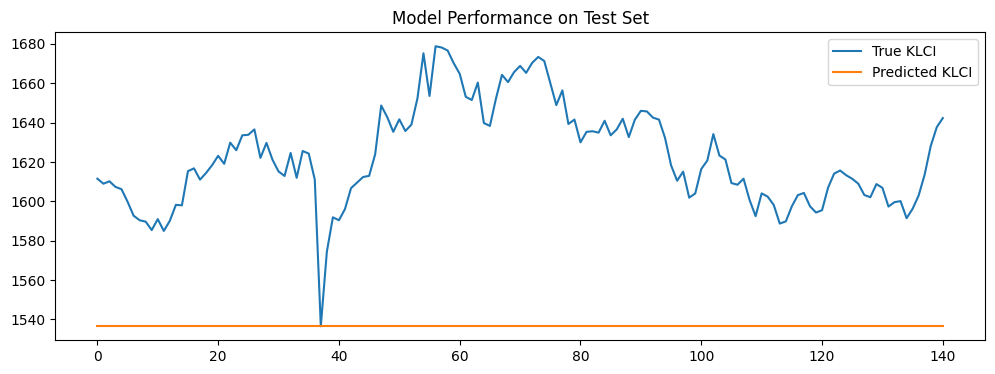

In [14]:
# Evaluate & Rescale Real Values
pred_norm = model.predict([Xtech_test, Xsenti_test]).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred = scaler_y.inverse_transform(pred_norm.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_true, label='True KLCI')
plt.plot(y_pred, label='Predicted KLCI')
plt.title('Model Performance on Test Set')
plt.legend()
plt.show()


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

MSE: 8040.19
RMSE: 89.67
MAE: 86.03


In [16]:
# Simulate Two-Year Forecast
last_tech = Xtech_test[-1:]
last_sent = Xsenti_test[-1:]
future = []

for _ in range(504):  # approx 2 trading years
    pred = model.predict([last_tech, last_sent])[0,0]
    future.append(pred)

    # shift and append new data (you can loop forward your close and sentiment)
    last_tech = np.roll(last_tech, -1, axis=1)
    last_tech[0,-1,:] = np.concatenate([last_tech[0,-1,:len(tech_feats)-1], last_tech[0,-1,-1:]])  # placeholder
    last_sent = np.roll(last_sent, -1, axis=1)
    last_sent[0,-1,:] = last_sent[0,-1,:]  # placeholder


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

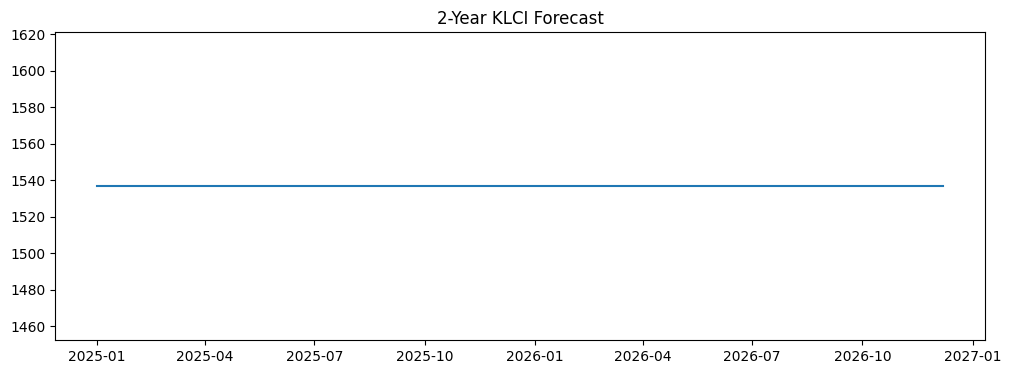

In [17]:
# Visualize Forecast Horizon
future_real = scaler_y.inverse_transform(np.array(future).reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(pd.date_range(start=df_y.index[-1], periods=len(future)+1, freq='B')[1:], future_real)
plt.title('2-Year KLCI Forecast')
plt.show()


In [18]:
y_train.min()

np.float64(0.0)